# Pareto Analysis of HGQ2 Quantization Bit-Width Sweep

Visualize the trade-off between model accuracy and hardware resource usage (EBOPs, LUTs, DSPs) across random quantizer configurations.

The Pareto frontier highlights configurations that achieve the best accuracy for a given resource budget.

## Imports

In [8]:
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

## Load sweep results

In [9]:
state_path = Path("qat_sweep_state.json")
all_runs = json.loads(state_path.read_text())

# Filter out runs with missing results (e.g. parse failures)
runs = [r for r in all_runs if r.get("accuracy") is not None]
print(f"Loaded {len(runs)} valid runs out of {len(all_runs)} total")

# Extract arrays for plotting
accuracy = np.array([r["accuracy"] for r in runs])
ebops = np.array([r["ebops"] for r in runs])
luts = np.array([r["luts"] for r in runs])
dsps = np.array([r["dsps"] for r in runs])
weight_bits = np.array([r["weight_b0"] for r in runs])

Loaded 38 valid runs out of 39 total


## Helper: plot Accuracy vs resource with Pareto frontier

In [10]:
def plot_pareto(x, y, xlabel, filename, color_values=None, color_label=None):
    """Scatter plot with Pareto frontier overlay."""
    # Sort by x and compute Pareto frontier (max y so far)
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_sorted = y[idx]

    px, py = [], []
    max_y = -1.0
    for i in range(len(x_sorted)):
        if y_sorted[i] > max_y:
            max_y = y_sorted[i]
            px.append(x_sorted[i])
            py.append(y_sorted[i])

    fig, ax = plt.subplots(figsize=(8, 5))

    # Scatter points, optionally colored
    if color_values is not None:
        sc = ax.scatter(x, y * 100, c=color_values, cmap='viridis',
                        alpha=0.7, edgecolors='k', linewidth=0.5)
        cb = fig.colorbar(sc, ax=ax)
        cb.set_label(color_label or '')
    else:
        ax.scatter(x, y * 100, alpha=0.7, edgecolors='k', linewidth=0.5)

    # Pareto frontier
    ax.plot(px, np.array(py) * 100, 'r--', linewidth=1.5, label='Pareto frontier')
    ax.scatter(px, np.array(py) * 100, c='red', marker='s', s=40, zorder=5)

    # Labels with directional arrows
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Accuracy (\%) $\uparrow$')
    ax.legend()
    ax.set_title(f'{xlabel} vs Accuracy')

    fig.tight_layout()
    fig.savefig(f'figures/{filename}.pdf')
    plt.show()

### Accuracy vs EBOPs (Estimated Bit-OPerations)

EBOPs is a proxy for dynamic power consumption. Lower is better. Color indicates weight bit-width.

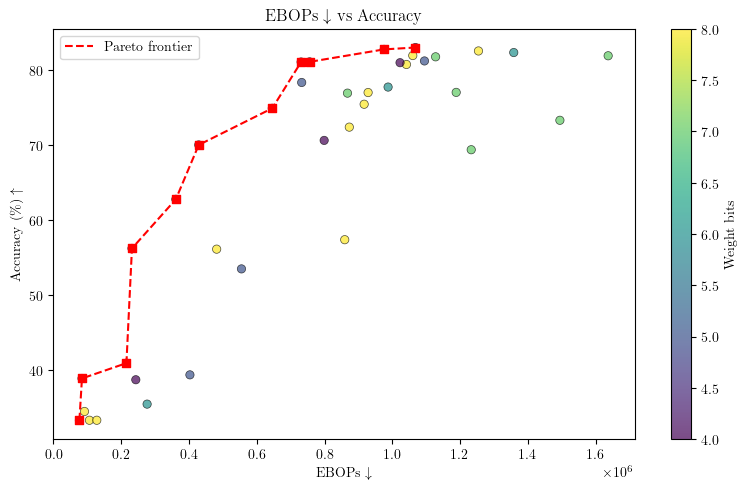

In [11]:
plot_pareto(
    ebops, accuracy,
    xlabel=r'EBOPs $\downarrow$',
    filename='pareto_ebops',
    color_values=weight_bits,
    color_label='Weight bits',
)

### Accuracy vs LUTs (Look-Up Tables)

LUTs measure FPGA fabric usage. Lower is better. Color indicates weight bit-width.

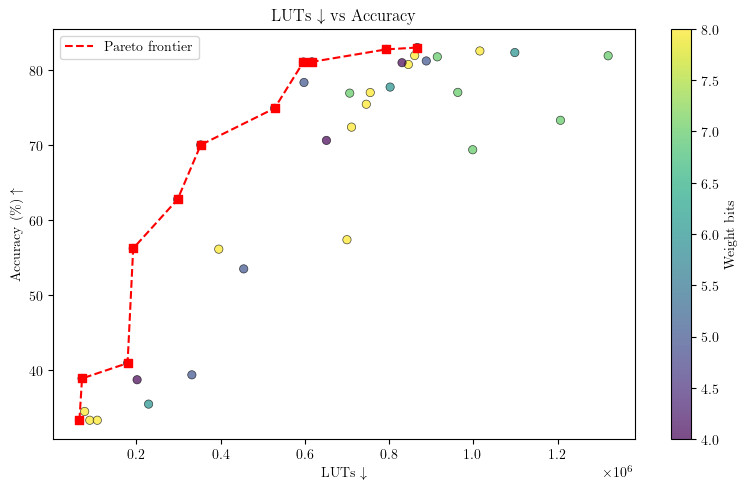

In [12]:
plot_pareto(
    luts, accuracy,
    xlabel=r'LUTs $\downarrow$',
    filename='pareto_luts',
    color_values=weight_bits,
    color_label='Weight bits',
)

### Accuracy vs DSPs (DSP slices)

DSPs are dedicated arithmetic blocks on the FPGA. Lower is better. Color indicates weight bit-width.

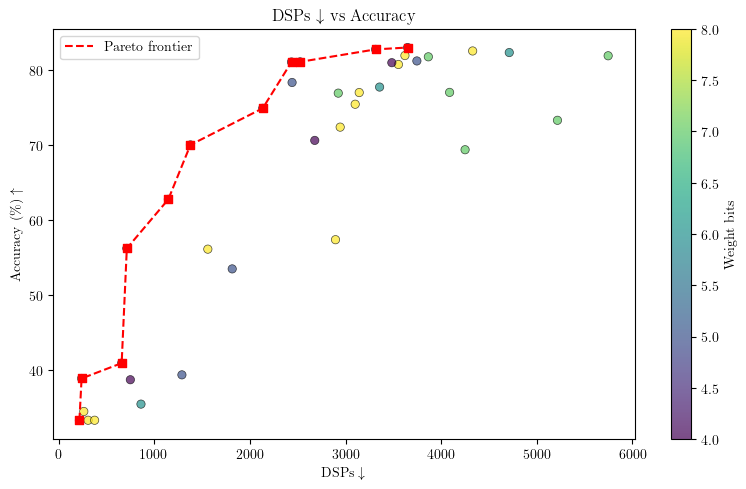

In [13]:
plot_pareto(
    dsps, accuracy,
    xlabel=r'DSPs $\downarrow$',
    filename='pareto_dsps',
    color_values=weight_bits,
    color_label='Weight bits',
)

## Summary of Pareto-optimal configurations

In [16]:
def pareto_points(x, y):
    """Return indices of points on the Pareto frontier (minimize x, maximize y)."""
    idx = np.argsort(x)
    result = []
    max_y = -1.0
    for i in idx:
        if y[i] > max_y:
            max_y = y[i]
            result.append(i)
    return result

# Only consider runs with >= 80% accuracy for the summary
mask = accuracy >= 0.80
high_acc_runs = [r for m, r in zip(mask, runs) if m]
print(f"Runs with accuracy >= 80%: {len(high_acc_runs)} out of {len(runs)}\n")

keys = {'ebops': ebops[mask], 'luts': luts[mask], 'dsps': dsps[mask]}
acc_high = accuracy[mask]

print("Pareto-optimal configurations (accuracy >= 80%):\n")
print(f"{'Run ID':<12} {'Acc':>6} {'EBOPs':>8} {'LUTs':>8} {'DSPs':>6}  "
      f"{'w_i0':>4} {'w_b0':>4} {'b_i0':>4} {'b_b0':>4} {'d_i0':>4} {'d_f0':>4}")
print("-" * 75)

for key, label in [('ebops', 'EBOPs'), ('luts', 'LUTs'), ('dsps', 'DSPs')]:
    print(f"\nBy {label}:")
    for i in pareto_points(keys[key], acc_high):
        r = high_acc_runs[i]
        print(f"{r['run_id']:<12} {r['accuracy']*100:>5.1f}% {r[key]:>8} "
              f"{r['luts']:>8} {r['dsps']:>6}  "
              f"{r['weight_i0']:>4} {r['weight_b0']:>4} {r['bias_i0']:>4} "
              f"{r['bias_b0']:>4} {r['datalane_i0']:>4} {r['datalane_f0']:>4}")

Runs with accuracy >= 80%: 12 out of 38

Pareto-optimal configurations (accuracy >= 80%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_i0 w_b0 b_i0 b_b0 d_i0 d_f0
---------------------------------------------------------------------------

By EBOPs:
run_0004      81.1%   730533   596603   2435     1    5    2    3    3    4
run_0011      81.1%   755673   616821   2525     1    5    2    4    2    3
run_0027      82.8%   975399   793130   3314     1    5    4    3    4    4
run_0002      83.0%  1067677   866988   3649     1    4    1    5    1    4

By LUTs:
run_0004      81.1%   596603   596603   2435     1    5    2    3    3    4
run_0011      81.1%   616821   616821   2525     1    5    2    4    2    3
run_0027      82.8%   793130   793130   3314     1    5    4    3    4    4
run_0002      83.0%   866988   866988   3649     1    4    1    5    1    4

By DSPs:
run_0004      81.1%     2435   596603   2435     1    5    2    3    3    4
run_0011      81.1%     2525   616821   25